## Load and prepare final dataframe for model

In [1]:
# Load df_artists, df_songs, and df_artists_network_metrics from CSV with all columns visible in head/sample output.

import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 50)

df_artists = pd.read_csv('/Users/jamesemcnally/Documents/GitHub/spring-2026-hitmakers/df_artists.csv')
print(df_artists.shape)

df_songs = pd.read_csv('/Users/jamesemcnally/Documents/GitHub/spring-2026-hitmakers/df_songs.csv')
print(df_songs.shape)

df_artists_network_metrics = pd.read_csv('/Users/jamesemcnally/Documents/GitHub/spring-2026-hitmakers/df_artists_network_metrics.csv')
print(df_artists_network_metrics.shape)


(13655, 44)
(38383, 43)
(13609, 26)


In [2]:
df_artists_network_metrics.head()

,name,musicbrainz_artist_id,degree_centrality_top20_yearly,degree_centrality_firstsong_yearly,degree_centrality_top20_rolling5,degree_centrality_firstsong_rolling5,closeness_centrality_top20_yearly,closeness_centrality_firstsong_yearly,closeness_centrality_top20_rolling5,closeness_centrality_firstsong_rolling5,harmonic_closeness_centrality_top20_yearly,harmonic_closeness_centrality_firstsong_yearly,harmonic_closeness_centrality_top20_rolling5,harmonic_closeness_centrality_firstsong_rolling5,betweenness_centrality_top20_yearly,betweenness_centrality_firstsong_yearly,betweenness_centrality_top20_rolling5,betweenness_centrality_firstsong_rolling5,eigenvector_centrality_top20_yearly,eigenvector_centrality_firstsong_yearly,eigenvector_centrality_top20_rolling5,eigenvector_centrality_firstsong_rolling5,power_of_connected_artists_top20_yearly,power_of_connected_artists_firstsong_yearly,power_of_connected_artists_top20_rolling5,power_of_connected_artists_firstsong_rolling5
0,!!! (chk chk chk),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"""groove"" holmes",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,"""little"" jimmy dickens",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,"""pookie"" hudson",232958.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"""weird al"" yankovic",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Create df_artists_final: now focusing on ALL artists with a charting song (not just top 20)

In [3]:
# Create df_artists_final from df_artists:
# - drops non-feature/identifier columns and top-20 network columns
# - filters to all artists who first charted between 2000 and 2019 (any chart position)
# - merges in firstsong_rolling5 network metrics from df_artists_network_metrics
# - renames combined_major_genre_categories to combined_major_genre_categories_artist
# - creates charting_song_hitmaker target: 1 if artist has >1 charting song, 0 if exactly 1, null if none

top20_network_cols = [c for c in df_artists.columns if 'top20_rolling5' in c]

cols_to_drop = [
    'musicbrainz_artist_id', 'musicbrainz_mbid', 'spotify_id',
    'performer_pre_normalized', 'last_charting_song_year', 'first_song_year',
    'years_active_on_charts', 'first_charting_song_position',
    'first_charting_song_duration', 'genre_tags_musicbrainz',
    'first_year_on_chart_songs', 'genre_tags_through_first_top_10_hit',
    'major_genre_categories_through_first_top_10_hit',
    '#_of_major_genre_categories_through_first_top_10_hit',
    'musicbrainz_major_genre_categories', 'musicbrainz_#_of_genres',
    'spotify_genres', 'spotify_major_genre_categories',
    'top_20_hitmaker',
] + top20_network_cols

# Compute charting_song_hitmaker from df_songs
song_counts = df_songs.groupby('name')['title'].count().reset_index()
song_counts.columns = ['name', 'charting_song_count']
song_counts['charting_song_hitmaker'] = song_counts['charting_song_count'].apply(
    lambda x: 1 if x > 1 else (0 if x == 1 else None)
)

# Network metric columns to merge in
network_cols = [
    'name',
    'power_of_connected_artists_firstsong_rolling5',
    'eigenvector_centrality_firstsong_rolling5',
    'betweenness_centrality_firstsong_rolling5',
    'harmonic_closeness_centrality_firstsong_rolling5',
    'degree_centrality_firstsong_rolling5',
]

df_artists_final = (
    df_artists[df_artists['first_charting_song_year'].between(2000, 2019)]
    .drop(columns=[c for c in cols_to_drop if c in df_artists.columns])
    .rename(columns={'combined_major_genre_categories': 'combined_major_genre_categories_artist'})
    .reset_index(drop=True)
    .merge(df_artists_network_metrics[network_cols], on='name', how='left')
    .merge(song_counts[['name', 'charting_song_hitmaker']], on='name', how='left')
)

print(df_artists_final.shape)
print()
print("charting_song_hitmaker distribution:")
print(df_artists_final['charting_song_hitmaker'].value_counts(dropna=False))
print(f"\n  Hitmakers (>1 song):     {(df_artists_final['charting_song_hitmaker'] == 1).sum()}")
print(f"  Non-hitmakers (1 song):  {(df_artists_final['charting_song_hitmaker'] == 0).sum()}")
print(f"  Null (no charting songs): {df_artists_final['charting_song_hitmaker'].isna().sum()}")


(1974, 26)

charting_song_hitmaker distribution:
charting_song_hitmaker
0    1003
1     971
Name: count, dtype: int64

  Hitmakers (>1 song):     971
  Non-hitmakers (1 song):  1003
  Null (no charting songs): 0


In [4]:
# Count null values in combined_major_genre_categories_artist
n_null = df_artists_final['combined_major_genre_categories_artist'].isna().sum()
n_total = len(df_artists_final)
print(f"Null: {n_null} / {n_total} ({n_null/n_total:.1%})")


Null: 577 / 1974 (29.2%)


#### *Only using artist genre tags*

In [5]:
# One-hot encode combined_major_genre_categories_artist into binary columns in df_artists_final.
# Splits comma-separated genre strings, creates one binary column per genre,
# prefixed with 'artist_genre_', replacing the original column.
# Also adds #_of_genres_artist (count of distinct genres per artist) after artist_genre_unknown.

# Compute genre count before dropping the original column
genre_counts = (
    df_artists_final['combined_major_genre_categories_artist']
    .fillna('')
    .apply(lambda x: len([g for g in x.split(', ') if g.strip()]) if x else 0)
)

artist_genre_dummies = (
    df_artists_final['combined_major_genre_categories_artist']
    .fillna('')
    .str.split(', ')
    .explode()
    .str.strip()
    .pipe(lambda s: pd.get_dummies(s, prefix='artist_genre'))
    .groupby(level=0)
    .max()
)

# Remove the empty-string column if it exists (from NaN rows)
artist_genre_dummies = artist_genre_dummies.loc[:, artist_genre_dummies.columns != 'artist_genre_']

# Insert genre columns where combined_major_genre_categories_artist was, then drop original
insert_at = df_artists_final.columns.get_loc('combined_major_genre_categories_artist')
df_artists_final = pd.concat([
    df_artists_final.iloc[:, :insert_at],
    artist_genre_dummies,
    df_artists_final.iloc[:, insert_at + 1:]
], axis=1)

# Add binary flag for artists with no genre data — inserted after last genre column
all_genre_cols = [c for c in df_artists_final.columns if c.startswith(('artist_genre_', 'song_genre_'))]
last_genre_idx = df_artists_final.columns.get_loc(all_genre_cols[-1])
df_artists_final.insert(last_genre_idx + 1, 'artist_genre_unknown', (df_artists_final[all_genre_cols].sum(axis=1) == 0).astype(int))

# Insert #_of_genres_artist after artist_genre_unknown
unknown_idx = df_artists_final.columns.get_loc('artist_genre_unknown')
df_artists_final.insert(unknown_idx + 1, '#_of_genres_artist', genre_counts)

print("Artist genre columns added:", artist_genre_dummies.columns.tolist())
print("df_artists_final shape:", df_artists_final.shape)


Artist genre columns added: ['artist_genre_Blues', 'artist_genre_Classical', 'artist_genre_Country/Americana', 'artist_genre_Easy Listening/Vocal', 'artist_genre_Electronic/Dance', 'artist_genre_Experimental/Avant-Garde', 'artist_genre_Folk', 'artist_genre_Gospel/Christian/Religious', 'artist_genre_Hip Hop/Rap', 'artist_genre_Jazz', 'artist_genre_Latin', 'artist_genre_Metal', 'artist_genre_Pop', 'artist_genre_Punk/Hardcore', 'artist_genre_R&B/Soul/Funk', 'artist_genre_Reggae/Caribbean', 'artist_genre_Rock', 'artist_genre_World Music']
df_artists_final shape: (1974, 45)


In [6]:
df_artists_final.head()

,name,first_top_20_hit_year,first_charting_song_year,years_through_first_top_20_hit,#_of_charting_songs_through_first_top_20_hit,top_20_hit_song_#_wks_on_chart_any_position,artist_genre_Blues,artist_genre_Classical,artist_genre_Country/Americana,artist_genre_Easy Listening/Vocal,artist_genre_Electronic/Dance,artist_genre_Experimental/Avant-Garde,artist_genre_Folk,artist_genre_Gospel/Christian/Religious,artist_genre_Hip Hop/Rap,artist_genre_Jazz,artist_genre_Latin,artist_genre_Metal,artist_genre_Pop,artist_genre_Punk/Hardcore,artist_genre_R&B/Soul/Funk,artist_genre_Reggae/Caribbean,artist_genre_Rock,artist_genre_World Music,artist_genre_unknown,#_of_genres_artist,first_top_20_song_major_genres,first_top_20_song_duration_ms,first_top_20_song_acousticness,first_top_20_song_danceability,first_top_20_song_energy,first_top_20_song_instrumentalness,first_top_20_song_liveness,first_top_20_song_loudness,first_top_20_song_speechiness,first_top_20_song_tempo,first_top_20_song_valence,first_top_20_song_mode,first_top_20_song_explicit,power_of_connected_artists_firstsong_rolling5,eigenvector_centrality_firstsong_rolling5,betweenness_centrality_firstsong_rolling5,harmonic_closeness_centrality_firstsong_rolling5,degree_centrality_firstsong_rolling5,charting_song_hitmaker
0,(+44),NaN,2006.0,NaN,NaN,NaN,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,10 years,NaN,2006.0,NaN,NaN,NaN,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,0,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.875829e-16,0.000000,1.000000,0.000069,0
2,2 chainz,2012.0,2012.0,1.0,9.0,27.0,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7104.5,1.510211e-01,0.010130,5314.363492,0.006764,1
3,2 pistols,NaN,2008.0,NaN,NaN,NaN,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,393.0,1.222370e-02,0.000001,3232.199206,0.000506,0
4,21 savage,2017.0,2016.0,2.0,15.0,41.0,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1364.0,4.215328e-02,0.000737,4946.386508,0.001777,1


In [7]:
# Calculate weeks on chart for each artist's first charting song (any position).
# Sorts by first_charting_year and takes the earliest song per artist.
# Adds first_charting_song_wks_on_chart column to df_artists_final.

first_song_wks = (
    df_songs
    .sort_values('first_charting_year')
    .groupby('name', as_index=False)
    .first()[['name', 'wks_on_chart']]
    .rename(columns={'wks_on_chart': 'first_charting_song_wks_on_chart'})
)

df_artists_final = df_artists_final.merge(first_song_wks, on='name', how='left')

print(f"Null values: {df_artists_final['first_charting_song_wks_on_chart'].isna().sum()}")
print(df_artists_final['first_charting_song_wks_on_chart'].describe())


Null values: 0
count    1974.000000
mean       13.377913
std        11.115668
min         1.000000
25%         3.000000
50%        12.000000
75%        20.000000
max        79.000000
Name: first_charting_song_wks_on_chart, dtype: float64


In [8]:
# Drop rows with null charting_song_hitmaker, identifier columns, top-20 specific columns,
# first_top_20_song genre/spotify columns, and duplicates. Confirm shape and class balance.

cols_to_drop = [
    'name',
    'first_top_20_hit_year',
    'years_through_first_top_20_hit',
    '#_of_charting_songs_through_first_top_20_hit',
    'top_20_hit_song_#_wks_on_chart_any_position',
    'first_top_20_song_major_genres',
    # Spotify audio columns
    'first_top_20_song_duration_ms', 'first_top_20_song_acousticness',
    'first_top_20_song_danceability', 'first_top_20_song_energy',
    'first_top_20_song_instrumentalness', 'first_top_20_song_liveness',
    'first_top_20_song_loudness', 'first_top_20_song_speechiness',
    'first_top_20_song_tempo', 'first_top_20_song_valence',
    'first_top_20_song_mode', 'first_top_20_song_key',
    'first_top_20_song_explicit', 'first_top_20_song_popularity',
]

df_artists_final = (
    df_artists_final
    .dropna(subset=['charting_song_hitmaker'])
    .drop(columns=[c for c in cols_to_drop if c in df_artists_final.columns])
    .drop_duplicates()
    .reset_index(drop=True)
)

print(df_artists_final.shape)
print()
print(df_artists_final['charting_song_hitmaker'].value_counts())


(1821, 28)

charting_song_hitmaker
1    948
0    873
Name: count, dtype: int64


In [9]:
# Cast bool genre columns to int (0/1) in df_artists_final.

genre_cols = [c for c in df_artists_final.columns if c.startswith('genre_')]
df_artists_final[genre_cols] = df_artists_final[genre_cols].astype(int)

print(df_artists_final.shape)
print(df_artists_final[genre_cols].dtypes.unique())


(1821, 28)
[]


#### *Check this next cell for decisions regarding null values*

In [10]:
# Impute missing values in df_artists_final:
# - Network metrics → fill with 0 (no collaboration data = no centrality)

network_metric_cols = [
    'degree_centrality_firstsong_rolling5',
    'harmonic_closeness_centrality_firstsong_rolling5',
    'betweenness_centrality_firstsong_rolling5',
    'eigenvector_centrality_firstsong_rolling5',
    'power_of_connected_artists_firstsong_rolling5',
]
for col in network_metric_cols:
    if col in df_artists_final.columns:
        df_artists_final[col] = df_artists_final[col].fillna(0)

print("Imputation complete.")
print(f"df_artists_final shape: {df_artists_final.shape}")
print(df_artists_final.isnull().sum()[df_artists_final.isnull().sum() > 0])


Imputation complete.
df_artists_final shape: (1821, 28)
Series([], dtype: int64)


In [13]:
# Drop power_of_connected_artists and degree_centrality due to multicollinearity.
# Both are redundant with eigenvector_centrality_firstsong_rolling5.

df_artists_final = df_artists_final.drop(columns=[
    'power_of_connected_artists_firstsong_rolling5',
    'degree_centrality_firstsong_rolling5',
], errors='ignore')

print(f"df_artists_final shape: {df_artists_final.shape}")
print(df_artists_final.columns.tolist())


df_artists_final shape: (1821, 26)
['first_charting_song_year', 'artist_genre_Blues', 'artist_genre_Classical', 'artist_genre_Country/Americana', 'artist_genre_Easy Listening/Vocal', 'artist_genre_Electronic/Dance', 'artist_genre_Experimental/Avant-Garde', 'artist_genre_Folk', 'artist_genre_Gospel/Christian/Religious', 'artist_genre_Hip Hop/Rap', 'artist_genre_Jazz', 'artist_genre_Latin', 'artist_genre_Metal', 'artist_genre_Pop', 'artist_genre_Punk/Hardcore', 'artist_genre_R&B/Soul/Funk', 'artist_genre_Reggae/Caribbean', 'artist_genre_Rock', 'artist_genre_World Music', 'artist_genre_unknown', '#_of_genres_artist', 'eigenvector_centrality_firstsong_rolling5', 'betweenness_centrality_firstsong_rolling5', 'harmonic_closeness_centrality_firstsong_rolling5', 'charting_song_hitmaker', 'first_charting_song_wks_on_chart']


In [14]:
df_artists_final.head()

,first_charting_song_year,artist_genre_Blues,artist_genre_Classical,artist_genre_Country/Americana,artist_genre_Easy Listening/Vocal,artist_genre_Electronic/Dance,artist_genre_Experimental/Avant-Garde,artist_genre_Folk,artist_genre_Gospel/Christian/Religious,artist_genre_Hip Hop/Rap,artist_genre_Jazz,artist_genre_Latin,artist_genre_Metal,artist_genre_Pop,artist_genre_Punk/Hardcore,artist_genre_R&B/Soul/Funk,artist_genre_Reggae/Caribbean,artist_genre_Rock,artist_genre_World Music,artist_genre_unknown,#_of_genres_artist,eigenvector_centrality_firstsong_rolling5,betweenness_centrality_firstsong_rolling5,harmonic_closeness_centrality_firstsong_rolling5,charting_song_hitmaker,first_charting_song_wks_on_chart
0,2006.0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,1,0,0.000000e+00,0.000000,0.000000,0,1
1,2006.0,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,0,2,2.875829e-16,0.000000,1.000000,0,2
2,2012.0,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,0,1,1.510211e-01,0.010130,5314.363492,1,1
3,2008.0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,1,0,1.222370e-02,0.000001,3232.199206,0,20
4,2016.0,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,0,1,4.215328e-02,0.000737,4946.386508,1,1


## Model

In [15]:
# Drop columns not used as model features
cols_to_drop = ['first_charting_song_year']
df_artists_final = df_artists_final.drop(columns=[c for c in cols_to_drop if c in df_artists_final.columns])
print(df_artists_final.shape)


(1821, 25)


In [16]:
# Separate features and target
X = df_artists_final.drop(columns=['charting_song_hitmaker'])
y = df_artists_final['charting_song_hitmaker']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\ny value counts:\n{y.value_counts()}")
print(f"\ny class balance:\n{y.value_counts(normalize=True).round(3)}")


X shape: (1821, 24)
y shape: (1821,)

y value counts:
charting_song_hitmaker
1    948
0    873
Name: count, dtype: int64

y class balance:
charting_song_hitmaker
1    0.521
0    0.479
Name: proportion, dtype: float64


In [17]:
# Split into train and test sets, stratified to preserve class balance
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"\nTrain class balance:\n{y_train.value_counts(normalize=True).round(3)}")
print(f"\nTest class balance:\n{y_test.value_counts(normalize=True).round(3)}")


Train: (1456, 24), Test: (365, 24)

Train class balance:
charting_song_hitmaker
1    0.521
0    0.479
Name: proportion, dtype: float64

Test class balance:
charting_song_hitmaker
1    0.521
0    0.479
Name: proportion, dtype: float64


In [18]:
# Scale features for models sensitive to feature magnitude (Logistic Regression, SVM)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling complete.")
print(f"X_train_scaled shape: {X_train_scaled.shape}")


Scaling complete.
X_train_scaled shape: (1456, 24)


In [19]:
# Evaluate models using 5-fold cross-validation on training set only.
# Logistic Regression and SVM wrapped in pipelines with StandardScaler to ensure convergence.

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
import numpy as np

scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

models = {
    'Dummy':               DummyClassifier(strategy='stratified', random_state=42),
    'Logistic Regression': Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(max_iter=2000, random_state=42))]),
    'SVM':                 Pipeline([('scaler', StandardScaler()), ('clf', SVC(probability=True, random_state=42))]),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost':             XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss'),
}

results = []
for name, model in models.items():
    cv = cross_validate(model, X_train, y_train, cv=5, scoring=scoring, return_train_score=True)
    results.append({
        'Model':           name,
        'Accuracy':        cv['test_accuracy'].mean(),
        'Precision':       cv['test_precision'].mean(),
        'Recall':          cv['test_recall'].mean(),
        'F1':              cv['test_f1'].mean(),
        'ROC-AUC (CV)':    cv['test_roc_auc'].mean(),
        'ROC-AUC (Train)': cv['train_roc_auc'].mean(),
        'Overfit Gap':     cv['train_roc_auc'].mean() - cv['test_roc_auc'].mean(),
    })

df_results = pd.DataFrame(results).set_index('Model').round(3)
print(df_results)


                     Accuracy  Precision  Recall     F1  ROC-AUC (CV)  \
Model                                                                   
Dummy                   0.465      0.486   0.482  0.484         0.464   
Logistic Regression     0.683      0.681   0.734  0.705         0.728   
SVM                     0.676      0.669   0.751  0.707         0.722   
Random Forest           0.661      0.671   0.683  0.677         0.703   
XGBoost                 0.666      0.676   0.685  0.680         0.701   

                     ROC-AUC (Train)  Overfit Gap  
Model                                              
Dummy                          0.508        0.044  
Logistic Regression            0.749        0.021  
SVM                            0.804        0.082  
Random Forest                  0.987        0.284  
XGBoost                        0.983        0.283  


In [20]:
# Lightweight regularization pass for Random Forest and XGBoost.
# Goal: close overfit gaps before committing to full hyperparameter search.
# 20 iterations each, focused on depth and leaf/child weight controls.

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
from scipy.stats import randint, uniform

# --- Random Forest ---
rf_reg_grid = {
    'max_depth':        randint(3, 8),
    'min_samples_leaf': randint(10, 50),
    'min_samples_split':randint(10, 50),
    'max_features':     ['sqrt', 'log2', 0.5],
}

rf_reg_search = RandomizedSearchCV(
    RandomForestClassifier(n_estimators=100, random_state=42),
    rf_reg_grid,
    n_iter=20, cv=5, scoring='roc_auc',
    random_state=42, n_jobs=-1, verbose=1
)
rf_reg_search.fit(X_train, y_train)

# --- XGBoost ---
xgb_reg_grid = {
    'max_depth':        randint(2, 5),
    'min_child_weight': randint(10, 30),
    'reg_alpha':        uniform(1, 5),
    'reg_lambda':       uniform(3, 10),
    'subsample':        uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.5, 0.5),
}

xgb_reg_search = RandomizedSearchCV(
    XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42, eval_metric='logloss'),
    xgb_reg_grid,
    n_iter=20, cv=5, scoring='roc_auc',
    random_state=42, n_jobs=-1, verbose=1
)
xgb_reg_search.fit(X_train, y_train)

# --- Report ---
from sklearn.model_selection import cross_validate

print("\n" + "=" * 50)
for name, search in [('Random Forest', rf_reg_search), ('XGBoost', xgb_reg_search)]:
    cv = cross_validate(search.best_estimator_, X_train, y_train, cv=5,
                        scoring='roc_auc', return_train_score=True)
    print(f"{name}")
    print(f"  Best params:     {search.best_params_}")
    print(f"  ROC-AUC (CV):    {cv['test_score'].mean():.3f} ± {cv['test_score'].std():.3f}")
    print(f"  ROC-AUC (Train): {cv['train_score'].mean():.3f}")
    print(f"  Overfit Gap:     {cv['train_score'].mean() - cv['test_score'].mean():.3f}")
    print()


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Random Forest
  Best params:     {'max_depth': 5, 'max_features': 0.5, 'min_samples_leaf': 12, 'min_samples_split': 46}
  ROC-AUC (CV):    0.743 ± 0.041
  ROC-AUC (Train): 0.790
  Overfit Gap:     0.047

XGBoost
  Best params:     {'colsample_bytree': np.float64(0.855670976374325), 'max_depth': 4, 'min_child_weight': 10, 'reg_alpha': np.float64(4.029799873905057), 'reg_lambda': np.float64(12.26300878513349), 'subsample': np.float64(0.8604308102007778)}
  ROC-AUC (CV):    0.743 ± 0.039
  ROC-AUC (Train): 0.809
  Overfit Gap:     0.065



In [21]:
# Full hyperparameter search for Random Forest and XGBoost.
# 100 iterations each, 5-fold CV, optimizing ROC-AUC.
# Builds on regularization pass — search ranges informed by best params found above.

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, cross_validate
from xgboost import XGBClassifier
from scipy.stats import randint, uniform

# --- Random Forest ---
rf_grid = {
    'n_estimators':      randint(100, 500),
    'max_depth':         randint(3, 8),
    'min_samples_leaf':  randint(5, 50),
    'min_samples_split': randint(5, 50),
    'max_features':      ['sqrt', 'log2', 0.3, 0.5],
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    rf_grid,
    n_iter=100, cv=5, scoring='roc_auc',
    random_state=42, n_jobs=-1, verbose=1
)
rf_search.fit(X_train, y_train)

# --- XGBoost ---
xgb_grid = {
    'n_estimators':      randint(100, 400),
    'max_depth':         randint(2, 5),
    'learning_rate':     uniform(0.01, 0.1),
    'min_child_weight':  randint(10, 30),
    'subsample':         uniform(0.6, 0.4),
    'colsample_bytree':  uniform(0.5, 0.5),
    'reg_alpha':         uniform(1, 5),
    'reg_lambda':        uniform(3, 10),
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    xgb_grid,
    n_iter=100, cv=5, scoring='roc_auc',
    random_state=42, n_jobs=-1, verbose=1
)
xgb_search.fit(X_train, y_train)

# --- Report ---
print("\n" + "=" * 50)
for name, search in [('Random Forest', rf_search), ('XGBoost', xgb_search)]:
    cv = cross_validate(search.best_estimator_, X_train, y_train, cv=5,
                        scoring='roc_auc', return_train_score=True)
    print(f"{name}")
    print(f"  Best params:     {search.best_params_}")
    print(f"  ROC-AUC (CV):    {cv['test_score'].mean():.3f} ± {cv['test_score'].std():.3f}")
    print(f"  ROC-AUC (Train): {cv['train_score'].mean():.3f}")
    print(f"  Overfit Gap:     {cv['train_score'].mean() - cv['test_score'].mean():.3f}")
    print()


Fitting 5 folds for each of 100 candidates, totalling 500 fits
Fitting 5 folds for each of 100 candidates, totalling 500 fits

Random Forest
  Best params:     {'max_depth': 7, 'max_features': 0.3, 'min_samples_leaf': 12, 'min_samples_split': 31, 'n_estimators': 126}
  ROC-AUC (CV):    0.744 ± 0.042
  ROC-AUC (Train): 0.812
  Overfit Gap:     0.068

XGBoost
  Best params:     {'colsample_bytree': np.float64(0.6326011838408627), 'learning_rate': np.float64(0.03439896433790836), 'max_depth': 3, 'min_child_weight': 15, 'n_estimators': 150, 'reg_alpha': np.float64(5.460232775885567), 'reg_lambda': np.float64(9.311386259972629), 'subsample': np.float64(0.9179245214166594)}
  ROC-AUC (CV):    0.744 ± 0.038
  ROC-AUC (Train): 0.776
  Overfit Gap:     0.032



In [ ]:
# Hyperparameter tuning for Logistic Regression and SVM.
# 100 iterations for LR, 50 for SVM, 5-fold CV, optimizing ROC-AUC.
# Both wrapped in StandardScaler pipelines.
# SVM uses linear kernel only (rbf too slow with probability=True).
# Takes a long time (43 mins) to run for SVM

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV, cross_validate
from scipy.stats import loguniform

# --- Logistic Regression ---
lr_grid = {
    'clf__C':       loguniform(0.001, 100),
    'clf__penalty': ['l1', 'l2'],
    'clf__solver':  ['liblinear'],
}

lr_search = RandomizedSearchCV(
    Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(max_iter=5000, random_state=42))]),
    lr_grid,
    n_iter=100, cv=5, scoring='roc_auc',
    random_state=42, n_jobs=-1, verbose=1
)
lr_search.fit(X_train, y_train)

# --- SVM (linear kernel only — rbf too slow with probability=True) ---
svm_grid = {
    'clf__C':      loguniform(0.01, 100),
    'clf__kernel': ['linear'],
}

svm_search = RandomizedSearchCV(
    Pipeline([('scaler', StandardScaler()), ('clf', SVC(probability=True, random_state=42))]),
    svm_grid,
    n_iter=50, cv=5, scoring='roc_auc',
    random_state=42, n_jobs=-1, verbose=1
)
svm_search.fit(X_train, y_train)

# --- Report ---
print("\n" + "=" * 50)
for name, search in [('Logistic Regression', lr_search), ('SVM', svm_search)]:
    cv = cross_validate(search.best_estimator_, X_train, y_train, cv=5,
                        scoring='roc_auc', return_train_score=True)
    print(f"{name}")
    print(f"  Best params:     {search.best_params_}")
    print(f"  ROC-AUC (CV):    {cv['test_score'].mean():.3f} ± {cv['test_score'].std():.3f}")
    print(f"  ROC-AUC (Train): {cv['train_score'].mean():.3f}")
    print(f"  Overfit Gap:     {cv['train_score'].mean() - cv['test_score'].mean():.3f}")
    print()


Fitting 5 folds for each of 100 candidates, totalling 500 fits
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Logistic Regression
  Best params:     {'clf__C': np.float64(0.008263688714158009), 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}
  ROC-AUC (CV):    0.731 ± 0.038
  ROC-AUC (Train): 0.749
  Overfit Gap:     0.018

SVM
  Best params:     {'clf__C': np.float64(0.14742753159914673), 'clf__kernel': 'linear'}
  ROC-AUC (CV):    0.723 ± 0.042
  ROC-AUC (Train): 0.736
  Overfit Gap:     0.013



In [25]:
# Final evaluation of all four tuned models on the held-out test set.
# Reports ROC-AUC, log loss, accuracy, precision, recall, F1, and overfit gap.

from sklearn.metrics import (roc_auc_score, log_loss, accuracy_score,
                             precision_score, recall_score, f1_score,
                             classification_report)
from sklearn.model_selection import cross_validate

models_final = {
    'Logistic Regression': lr_search.best_estimator_,
    'SVM':                 svm_search.best_estimator_,
    'Random Forest':       rf_search.best_estimator_,
    'XGBoost':             xgb_search.best_estimator_,
}

summary = []
for name, model in models_final.items():
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    cv = cross_validate(model, X_train, y_train, cv=5,
                        scoring='roc_auc', return_train_score=True)
    print(f"{'='*52}")
    print(f"{name}")
    print(f"{'='*52}")
    print(f"  ROC-AUC (CV):    {cv['test_score'].mean():.3f} ± {cv['test_score'].std():.3f}")
    print(f"  ROC-AUC (Train): {cv['train_score'].mean():.3f}")
    print(f"  ROC-AUC (Test):  {roc_auc_score(y_test, y_proba):.3f}")
    print(f"  Overfit Gap:     {cv['train_score'].mean() - cv['test_score'].mean():.3f}")
    print(f"  Log Loss (Test): {log_loss(y_test, y_proba):.3f}")
    print(f"  Accuracy (Test): {accuracy_score(y_test, y_pred):.3f}")
    print(f"  Precision (Test):{precision_score(y_test, y_pred):.3f}")
    print(f"  Recall (Test):   {recall_score(y_test, y_pred):.3f}")
    print(f"  F1 (Test):       {f1_score(y_test, y_pred):.3f}")
    print(f"\n{classification_report(y_test, y_pred)}\n")
    summary.append({
        'Model':           name,
        'ROC-AUC (CV)':    cv['test_score'].mean(),
        'ROC-AUC (Train)': cv['train_score'].mean(),
        'ROC-AUC (Test)':  roc_auc_score(y_test, y_proba),
        'Overfit Gap':     cv['train_score'].mean() - cv['test_score'].mean(),
        'Log Loss':        log_loss(y_test, y_proba),
        'Accuracy':        accuracy_score(y_test, y_pred),
        'Precision':       precision_score(y_test, y_pred),
        'Recall':          recall_score(y_test, y_pred),
        'F1':              f1_score(y_test, y_pred),
    })

print("=" * 52)
print("FINAL COMPARISON (Test Set)")
print("=" * 52)
df_final = pd.DataFrame(summary).set_index('Model').round(3)
print(df_final.to_string())


Logistic Regression
  ROC-AUC (CV):    0.731 ± 0.038
  ROC-AUC (Train): 0.749
  ROC-AUC (Test):  0.731
  Overfit Gap:     0.018
  Log Loss (Test): 0.610
  Accuracy (Test): 0.690
  Precision (Test):0.697
  Recall (Test):   0.716
  F1 (Test):       0.706

              precision    recall  f1-score   support

           0       0.68      0.66      0.67       175
           1       0.70      0.72      0.71       190

    accuracy                           0.69       365
   macro avg       0.69      0.69      0.69       365
weighted avg       0.69      0.69      0.69       365


SVM
  ROC-AUC (CV):    0.723 ± 0.042
  ROC-AUC (Train): 0.736
  ROC-AUC (Test):  0.708
  Overfit Gap:     0.013
  Log Loss (Test): 0.636
  Accuracy (Test): 0.679
  Precision (Test):0.683
  Recall (Test):   0.716
  F1 (Test):       0.699

              precision    recall  f1-score   support

           0       0.67      0.64      0.66       175
           1       0.68      0.72      0.70       190

    accuracy    

Random Forest
  ROC-AUC (CV):    0.744 ± 0.042
  ROC-AUC (Train): 0.812
  ROC-AUC (Test):  0.753
  Overfit Gap:     0.068
  Log Loss:        0.595
  Brier Score:     0.203
  Accuracy:        0.715
  Precision:       0.709
  Recall:          0.768
  F1:              0.737

              precision    recall  f1-score   support

           0       0.72      0.66      0.69       175
           1       0.71      0.77      0.74       190

    accuracy                           0.72       365
   macro avg       0.72      0.71      0.71       365
weighted avg       0.72      0.72      0.71       365




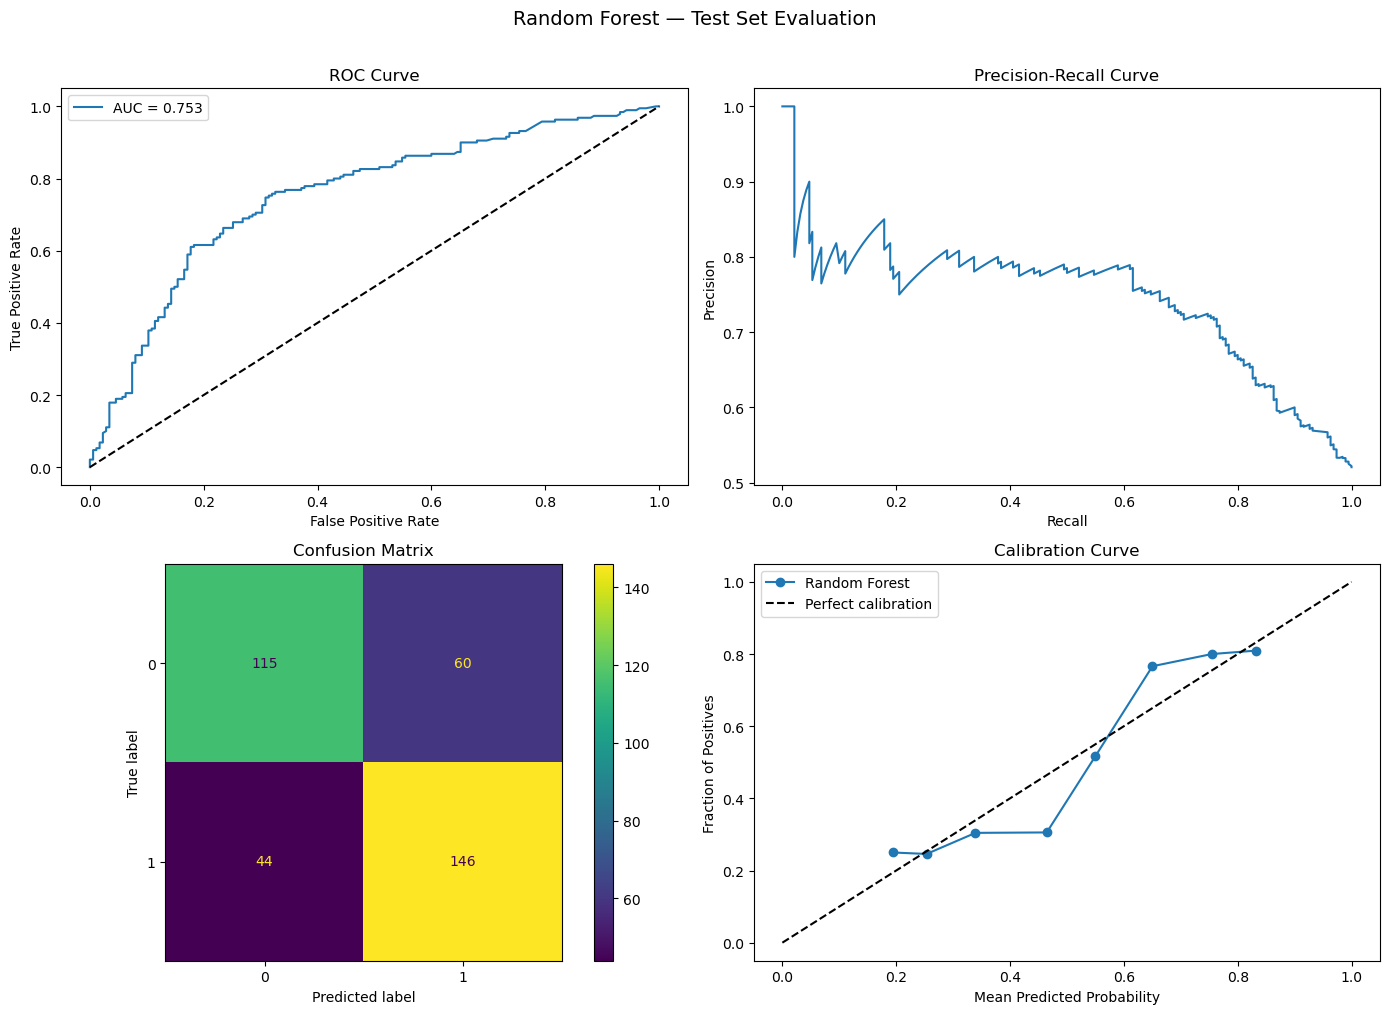


Feature Importance (mean absolute SHAP) — Random Forest:
                                         feature  mean_abs_shap
                              #_of_genres_artist       0.050650
                            artist_genre_unknown       0.045180
                        artist_genre_Hip Hop/Rap       0.040154
                first_charting_song_wks_on_chart       0.031166
                                artist_genre_Pop       0.028430
       eigenvector_centrality_firstsong_rolling5       0.025338
       betweenness_centrality_firstsong_rolling5       0.025089
                  artist_genre_Country/Americana       0.021640
                      artist_genre_R&B/Soul/Funk       0.013635
harmonic_closeness_centrality_firstsong_rolling5       0.012096
                   artist_genre_Electronic/Dance       0.010691
                               artist_genre_Rock       0.003766
                      artist_genre_Punk/Hardcore       0.001154
                               artist_genre_Ja

/opt/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/shap/plots/_beeswarm.py:1150: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()
/var/folders/1v/h2vyfq9j45n9_tmm_gg2s8tm0000gn/T/ipykernel_59173/1762712558.py:108: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


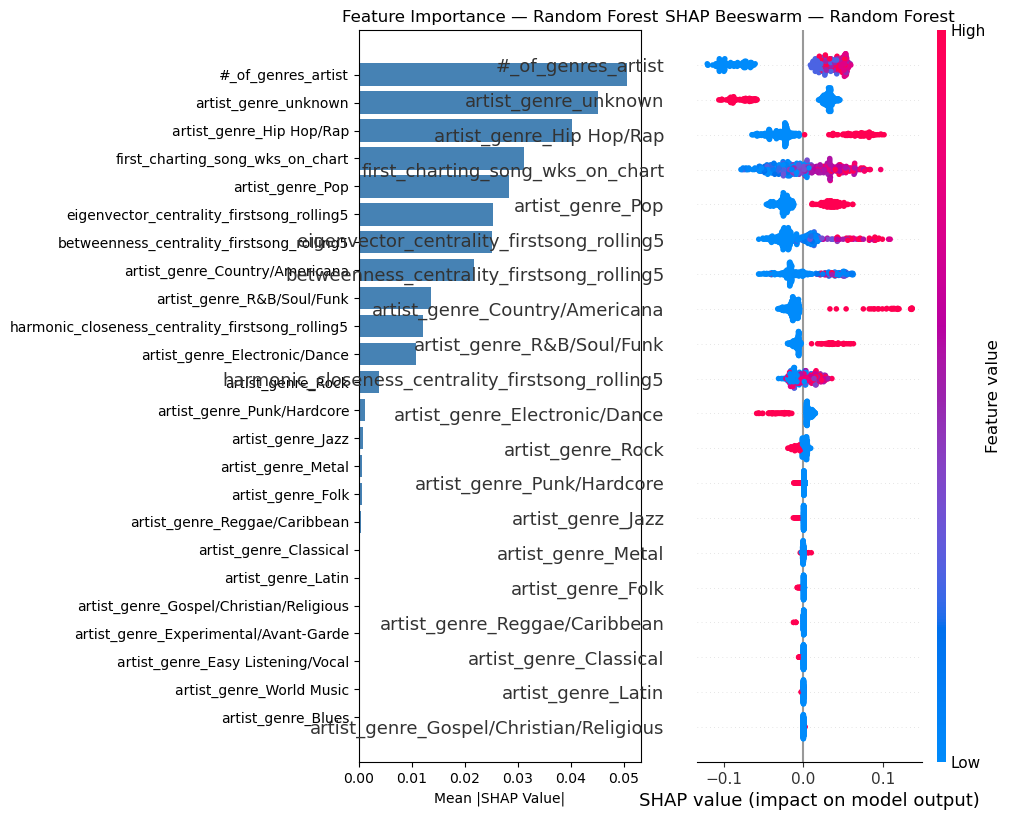

XGBoost
  ROC-AUC (CV):    0.744 ± 0.038
  ROC-AUC (Train): 0.776
  ROC-AUC (Test):  0.749
  Overfit Gap:     0.032
  Log Loss:        0.597
  Brier Score:     0.204
  Accuracy:        0.701
  Precision:       0.701
  Recall:          0.742
  F1:              0.721

              precision    recall  f1-score   support

           0       0.70      0.66      0.68       175
           1       0.70      0.74      0.72       190

    accuracy                           0.70       365
   macro avg       0.70      0.70      0.70       365
weighted avg       0.70      0.70      0.70       365




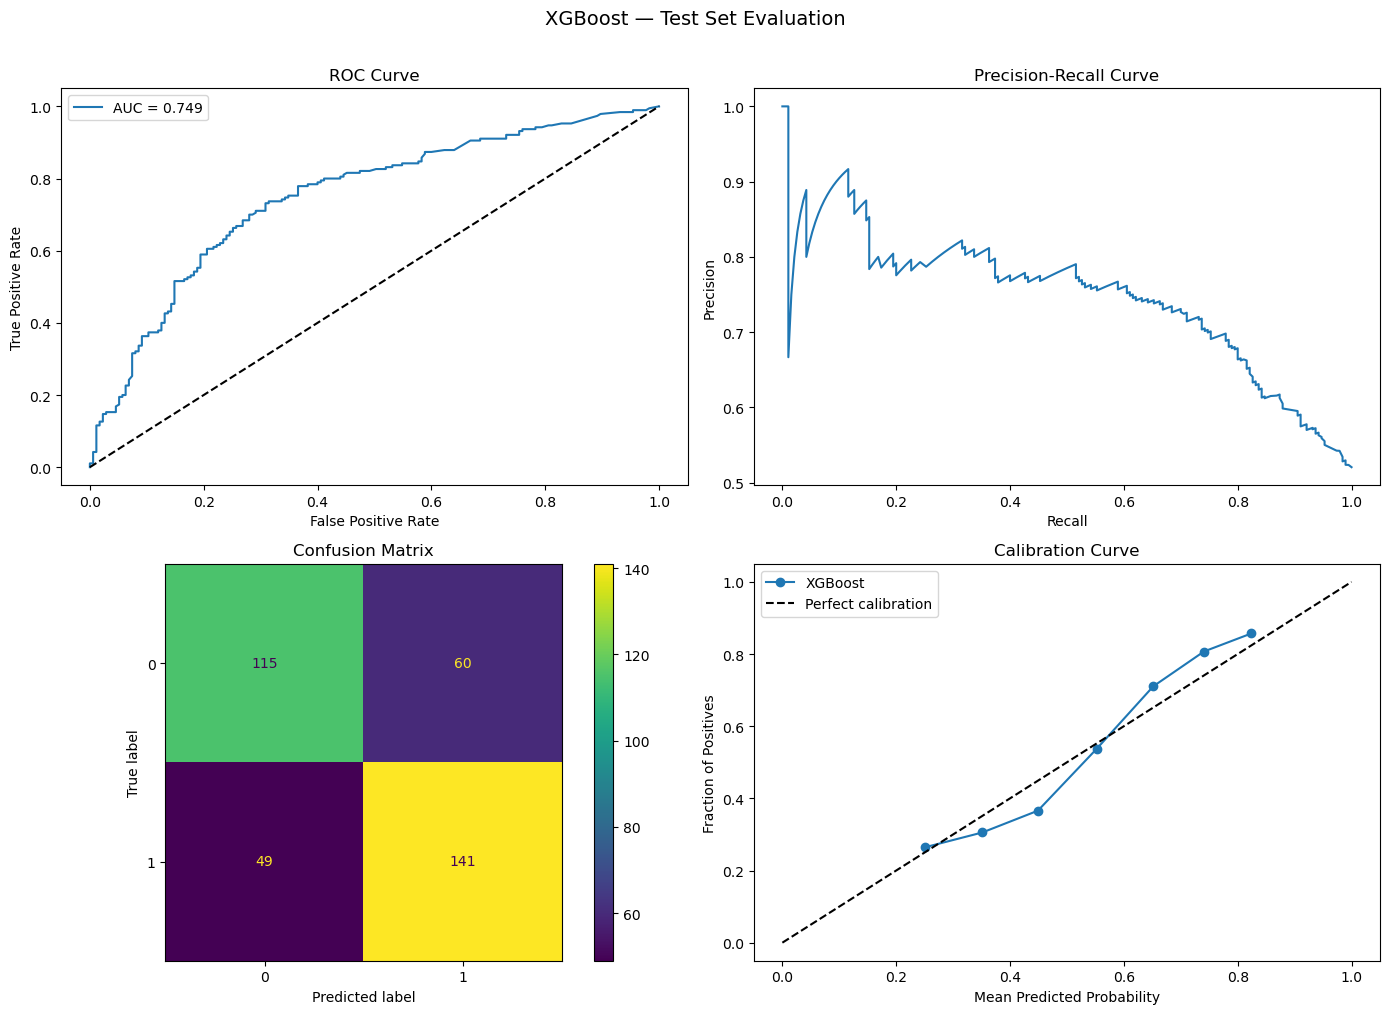


Feature Importance (mean absolute SHAP) — XGBoost:
                                         feature  mean_abs_shap
                            artist_genre_unknown       0.220462
                        artist_genre_Hip Hop/Rap       0.191937
                                artist_genre_Pop       0.180624
                first_charting_song_wks_on_chart       0.146064
       eigenvector_centrality_firstsong_rolling5       0.119158
                  artist_genre_Country/Americana       0.114093
       betweenness_centrality_firstsong_rolling5       0.106556
                              #_of_genres_artist       0.104075
                      artist_genre_R&B/Soul/Funk       0.064298
                   artist_genre_Electronic/Dance       0.052786
harmonic_closeness_centrality_firstsong_rolling5       0.045809
                               artist_genre_Rock       0.010132
                              artist_genre_Latin       0.000000
                              artist_genre_Metal    

/opt/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/shap/plots/_beeswarm.py:1150: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()
/var/folders/1v/h2vyfq9j45n9_tmm_gg2s8tm0000gn/T/ipykernel_59173/1762712558.py:108: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


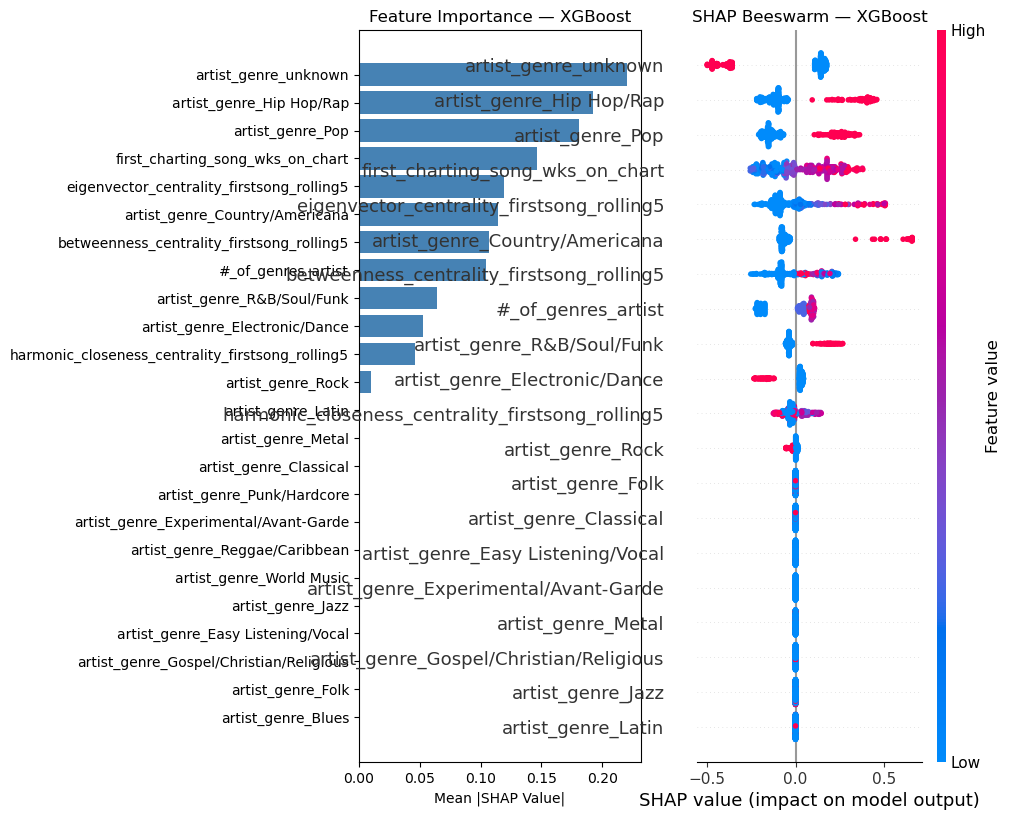

Logistic Regression
  ROC-AUC (CV):    0.731 ± 0.038
  ROC-AUC (Train): 0.749
  ROC-AUC (Test):  0.731
  Overfit Gap:     0.018
  Log Loss:        0.610
  Brier Score:     0.210
  Accuracy:        0.690
  Precision:       0.697
  Recall:          0.716
  F1:              0.706

              precision    recall  f1-score   support

           0       0.68      0.66      0.67       175
           1       0.70      0.72      0.71       190

    accuracy                           0.69       365
   macro avg       0.69      0.69      0.69       365
weighted avg       0.69      0.69      0.69       365




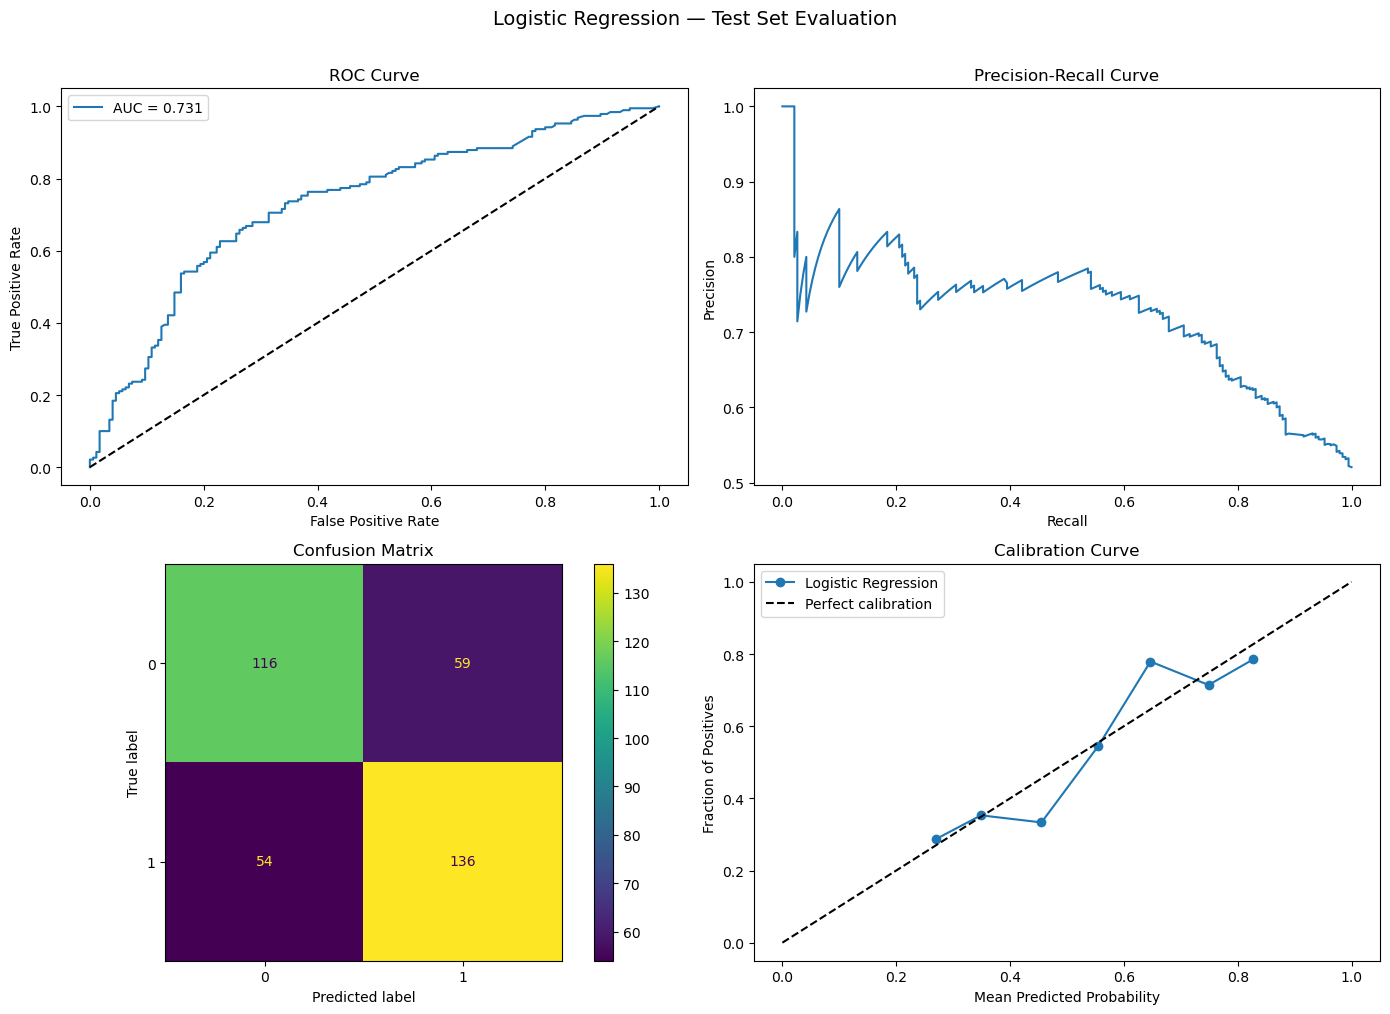

In [27]:
# Deep evaluation of Random Forest, XGBoost, and Logistic Regression on held-out test set.
# Includes ROC curve, confusion matrix, precision-recall curve, calibration curve, and SHAP importance.

import shap
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import (
    roc_auc_score, log_loss, accuracy_score, precision_score,
    recall_score, f1_score, classification_report, roc_curve,
    precision_recall_curve, ConfusionMatrixDisplay, brier_score_loss
)
from sklearn.calibration import calibration_curve
from sklearn.model_selection import cross_validate

models_to_eval = {
    'Random Forest':       (rf_search.best_estimator_,  X_train, X_test),
    'XGBoost':             (xgb_search.best_estimator_, X_train, X_test),
    'Logistic Regression': (lr_search.best_estimator_,  X_train, X_test),
}

for name, (model, X_tr, X_te) in models_to_eval.items():
    y_pred  = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]
    cv = cross_validate(model, X_tr, y_train, cv=5,
                        scoring='roc_auc', return_train_score=True)

    print("=" * 52)
    print(f"{name}")
    print("=" * 52)
    print(f"  ROC-AUC (CV):    {cv['test_score'].mean():.3f} ± {cv['test_score'].std():.3f}")
    print(f"  ROC-AUC (Train): {cv['train_score'].mean():.3f}")
    print(f"  ROC-AUC (Test):  {roc_auc_score(y_test, y_proba):.3f}")
    print(f"  Overfit Gap:     {cv['train_score'].mean() - cv['test_score'].mean():.3f}")
    print(f"  Log Loss:        {log_loss(y_test, y_proba):.3f}")
    print(f"  Brier Score:     {brier_score_loss(y_test, y_proba):.3f}")
    print(f"  Accuracy:        {accuracy_score(y_test, y_pred):.3f}")
    print(f"  Precision:       {precision_score(y_test, y_pred):.3f}")
    print(f"  Recall:          {recall_score(y_test, y_pred):.3f}")
    print(f"  F1:              {f1_score(y_test, y_pred):.3f}")
    print(f"\n{classification_report(y_test, y_pred)}\n")

    # --- Plots ---
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    axes[0, 0].plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_proba):.3f}')
    axes[0, 0].plot([0, 1], [0, 1], 'k--')
    axes[0, 0].set_xlabel('False Positive Rate')
    axes[0, 0].set_ylabel('True Positive Rate')
    axes[0, 0].set_title('ROC Curve')
    axes[0, 0].legend()

    prec, rec, _ = precision_recall_curve(y_test, y_proba)
    axes[0, 1].plot(rec, prec)
    axes[0, 1].set_xlabel('Recall')
    axes[0, 1].set_ylabel('Precision')
    axes[0, 1].set_title('Precision-Recall Curve')

    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[1, 0])
    axes[1, 0].set_title('Confusion Matrix')

    prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10)
    axes[1, 1].plot(prob_pred, prob_true, marker='o', label=name)
    axes[1, 1].plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
    axes[1, 1].set_xlabel('Mean Predicted Probability')
    axes[1, 1].set_ylabel('Fraction of Positives')
    axes[1, 1].set_title('Calibration Curve')
    axes[1, 1].legend()

    plt.suptitle(f'{name} — Test Set Evaluation', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

    # --- SHAP (tree-based models only) ---
    if name in ['Random Forest', 'XGBoost']:
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_te)

        # Handle both list (RF) and array (XGBoost) formats
        if isinstance(shap_values, list):
            sv = shap_values[1]  # class 1
        elif shap_values.ndim == 3:
            sv = shap_values[:, :, 1]  # (samples, features, classes) → class 1
        else:
            sv = shap_values

        shap_importance = (
            pd.DataFrame({
                'feature':       X_te.columns,
                'mean_abs_shap': np.abs(sv).mean(axis=0)
            })
            .sort_values('mean_abs_shap', ascending=False)
            .reset_index(drop=True)
        )

        print(f"\nFeature Importance (mean absolute SHAP) — {name}:")
        print(shap_importance.to_string(index=False))

        fig, axes = plt.subplots(1, 2, figsize=(18, 6))
        axes[0].barh(shap_importance['feature'][::-1],
                     shap_importance['mean_abs_shap'][::-1], color='steelblue')
        axes[0].set_xlabel('Mean |SHAP Value|')
        axes[0].set_title(f'Feature Importance — {name}')

        plt.sca(axes[1])
        shap.summary_plot(sv, X_te, plot_type='dot', show=False)
        axes[1].set_title(f'SHAP Beeswarm — {name}')
        plt.tight_layout()
        plt.show()


Random Forest
  ROC-AUC (CV):    0.744 ± 0.042
  ROC-AUC (Train): 0.812
  ROC-AUC (Test):  0.753
  Overfit Gap:     0.068
  Log Loss:        0.595
  Brier Score:     0.203
  Accuracy:        0.715
  Precision:       0.709
  Recall:          0.768
  F1:              0.737

              precision    recall  f1-score   support

           0       0.72      0.66      0.69       175
           1       0.71      0.77      0.74       190

    accuracy                           0.72       365
   macro avg       0.72      0.71      0.71       365
weighted avg       0.72      0.72      0.71       365




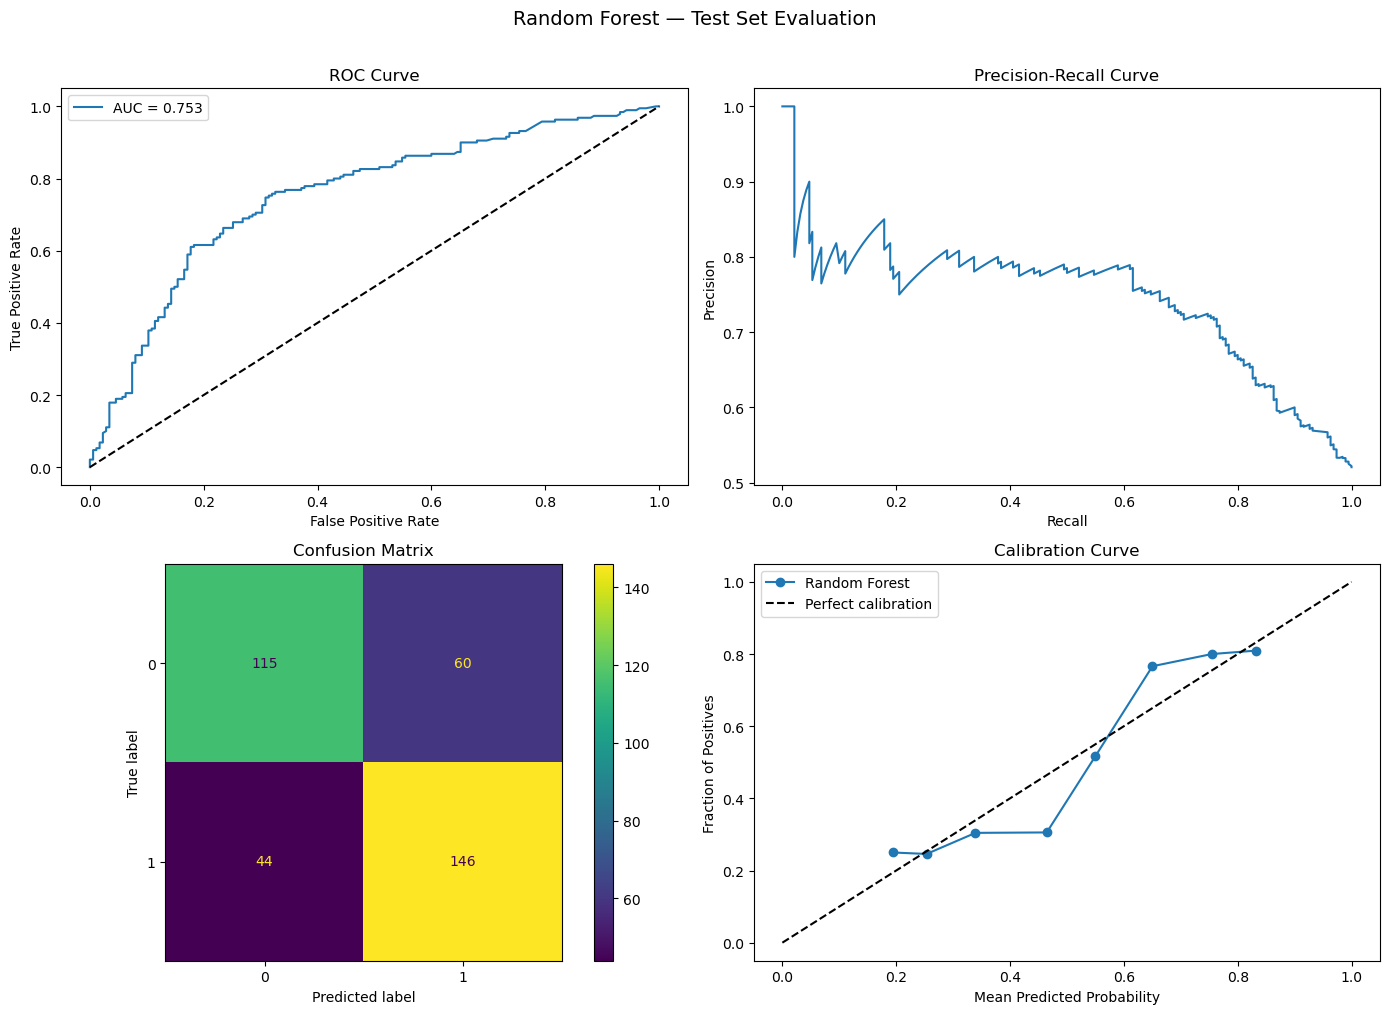


Feature Importance (mean absolute SHAP) — Random Forest:
                                         feature  mean_abs_shap
                              #_of_genres_artist       0.050650
                            artist_genre_unknown       0.045180
                        artist_genre_Hip Hop/Rap       0.040154
                first_charting_song_wks_on_chart       0.031166
                                artist_genre_Pop       0.028430
       eigenvector_centrality_firstsong_rolling5       0.025338
       betweenness_centrality_firstsong_rolling5       0.025089
                  artist_genre_Country/Americana       0.021640
                      artist_genre_R&B/Soul/Funk       0.013635
harmonic_closeness_centrality_firstsong_rolling5       0.012096
                   artist_genre_Electronic/Dance       0.010691
                               artist_genre_Rock       0.003766
                      artist_genre_Punk/Hardcore       0.001154
                               artist_genre_Ja

/opt/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/shap/plots/_beeswarm.py:1150: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()
/var/folders/1v/h2vyfq9j45n9_tmm_gg2s8tm0000gn/T/ipykernel_59173/1762712558.py:108: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


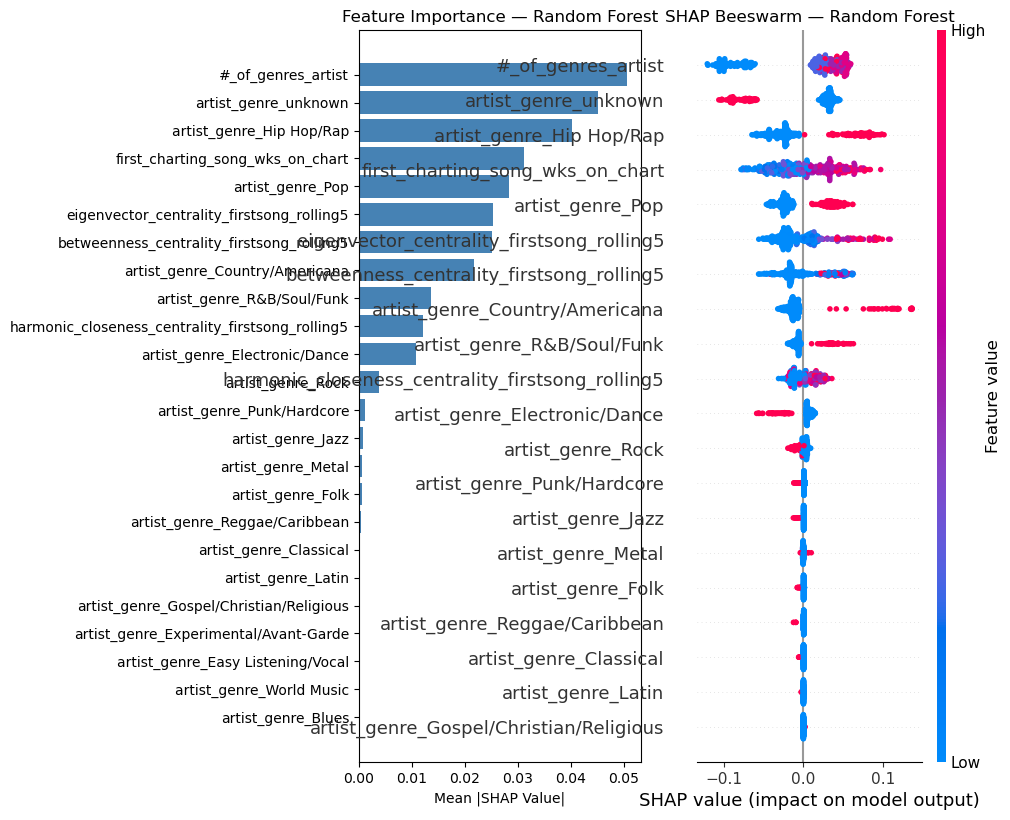

XGBoost
  ROC-AUC (CV):    0.744 ± 0.038
  ROC-AUC (Train): 0.776
  ROC-AUC (Test):  0.749
  Overfit Gap:     0.032
  Log Loss:        0.597
  Brier Score:     0.204
  Accuracy:        0.701
  Precision:       0.701
  Recall:          0.742
  F1:              0.721

              precision    recall  f1-score   support

           0       0.70      0.66      0.68       175
           1       0.70      0.74      0.72       190

    accuracy                           0.70       365
   macro avg       0.70      0.70      0.70       365
weighted avg       0.70      0.70      0.70       365




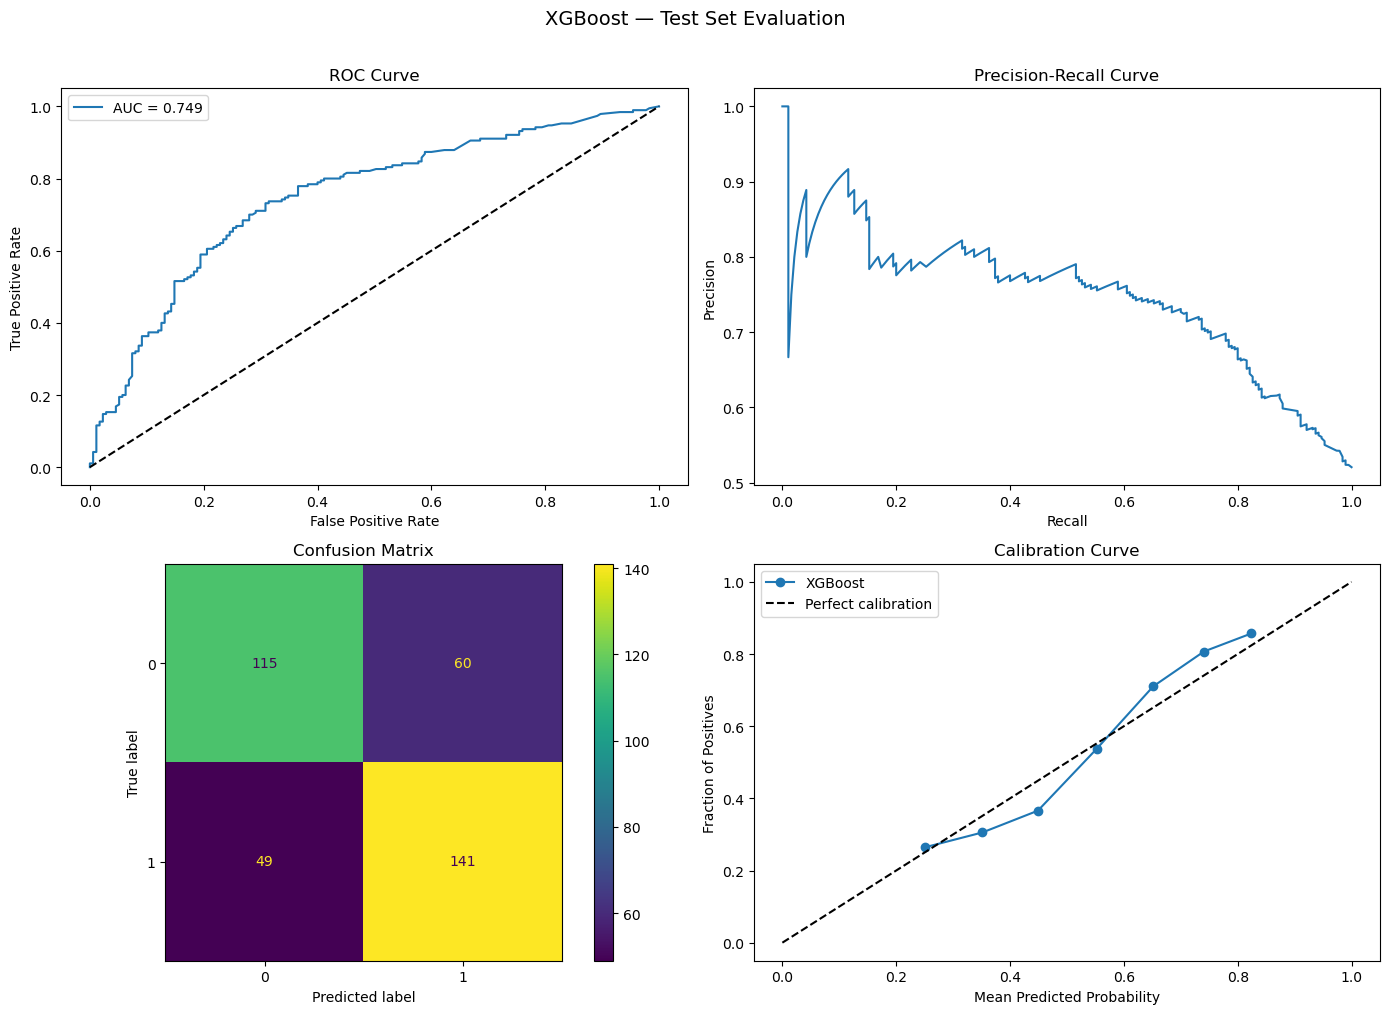


Feature Importance (mean absolute SHAP) — XGBoost:
                                         feature  mean_abs_shap
                            artist_genre_unknown       0.220462
                        artist_genre_Hip Hop/Rap       0.191937
                                artist_genre_Pop       0.180624
                first_charting_song_wks_on_chart       0.146064
       eigenvector_centrality_firstsong_rolling5       0.119158
                  artist_genre_Country/Americana       0.114093
       betweenness_centrality_firstsong_rolling5       0.106556
                              #_of_genres_artist       0.104075
                      artist_genre_R&B/Soul/Funk       0.064298
                   artist_genre_Electronic/Dance       0.052786
harmonic_closeness_centrality_firstsong_rolling5       0.045809
                               artist_genre_Rock       0.010132
                              artist_genre_Latin       0.000000
                              artist_genre_Metal    

/opt/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/shap/plots/_beeswarm.py:1150: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()
/var/folders/1v/h2vyfq9j45n9_tmm_gg2s8tm0000gn/T/ipykernel_59173/1762712558.py:108: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


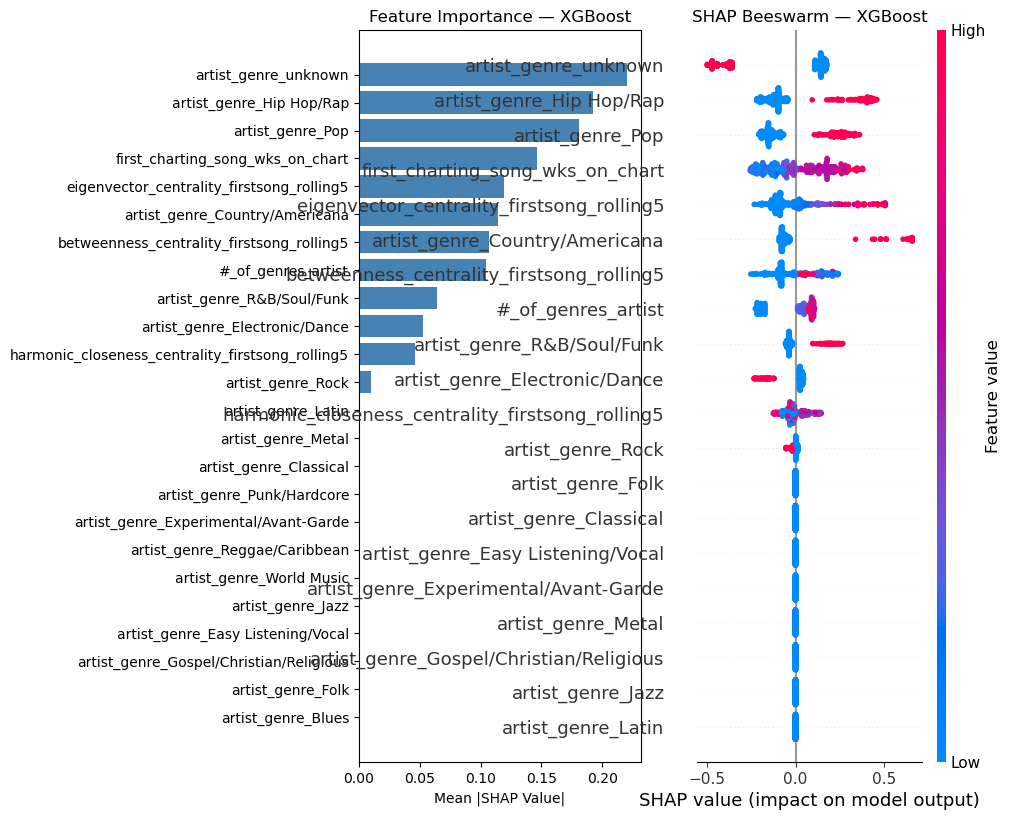

Logistic Regression
  ROC-AUC (CV):    0.731 ± 0.038
  ROC-AUC (Train): 0.749
  ROC-AUC (Test):  0.731
  Overfit Gap:     0.018
  Log Loss:        0.610
  Brier Score:     0.210
  Accuracy:        0.690
  Precision:       0.697
  Recall:          0.716
  F1:              0.706

              precision    recall  f1-score   support

           0       0.68      0.66      0.67       175
           1       0.70      0.72      0.71       190

    accuracy                           0.69       365
   macro avg       0.69      0.69      0.69       365
weighted avg       0.69      0.69      0.69       365




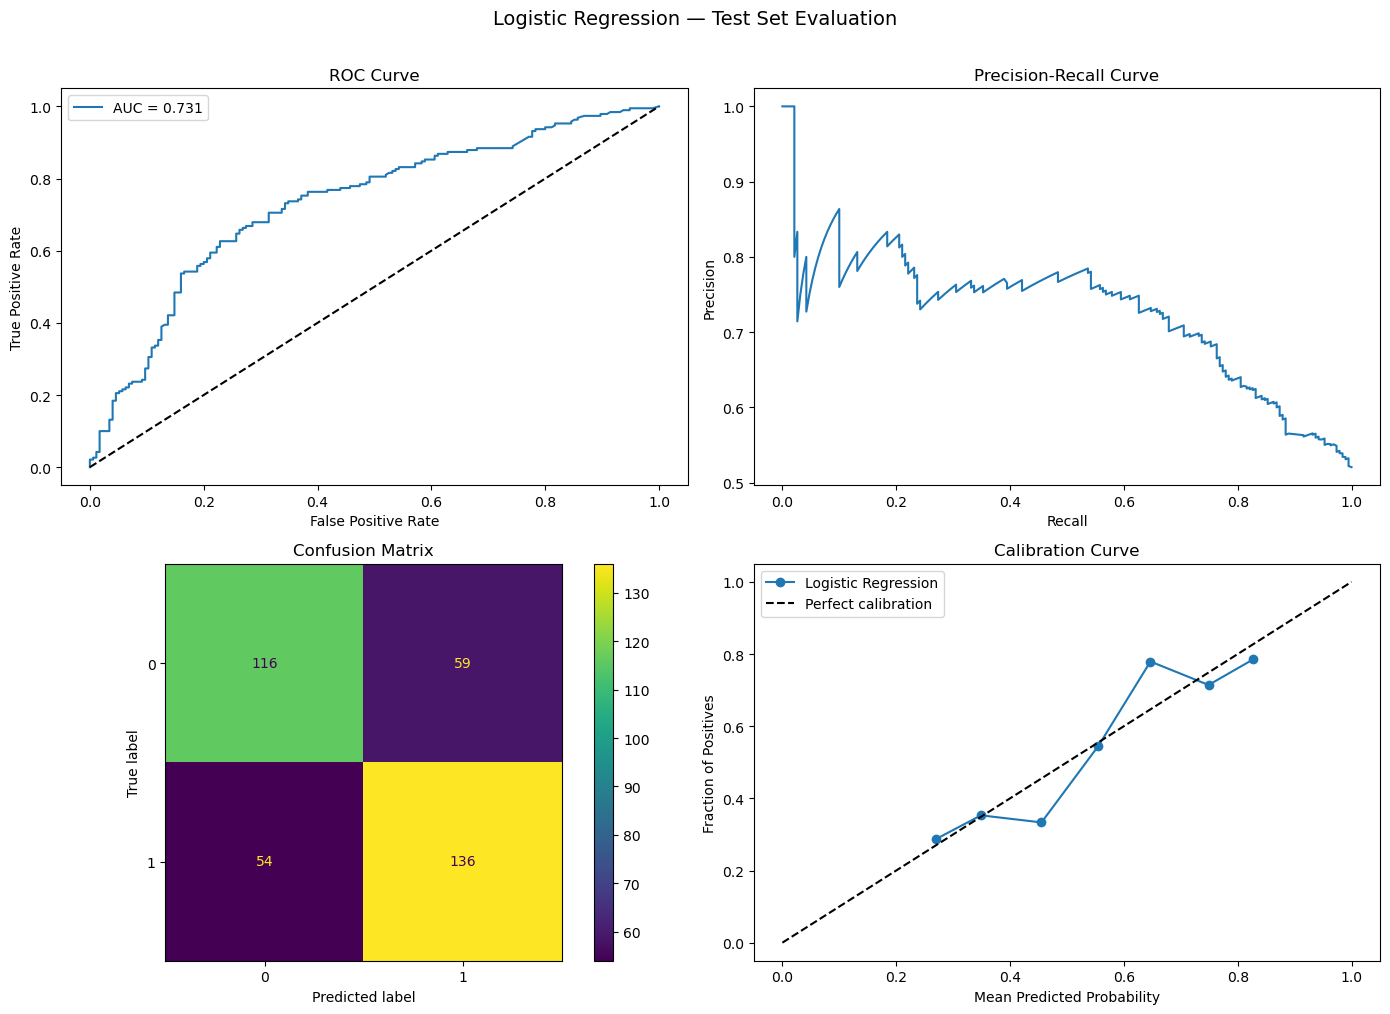

In [28]:
# Deep evaluation of Random Forest, XGBoost, and Logistic Regression on held-out test set.
# Includes ROC curve, confusion matrix, precision-recall curve, calibration curve, and SHAP importance.

import shap
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import (
    roc_auc_score, log_loss, accuracy_score, precision_score,
    recall_score, f1_score, classification_report, roc_curve,
    precision_recall_curve, ConfusionMatrixDisplay, brier_score_loss
)
from sklearn.calibration import calibration_curve
from sklearn.model_selection import cross_validate

models_to_eval = {
    'Random Forest':       (rf_search.best_estimator_,  X_train, X_test),
    'XGBoost':             (xgb_search.best_estimator_, X_train, X_test),
    'Logistic Regression': (lr_search.best_estimator_,  X_train, X_test),
}

for name, (model, X_tr, X_te) in models_to_eval.items():
    y_pred  = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]
    cv = cross_validate(model, X_tr, y_train, cv=5,
                        scoring='roc_auc', return_train_score=True)

    print("=" * 52)
    print(f"{name}")
    print("=" * 52)
    print(f"  ROC-AUC (CV):    {cv['test_score'].mean():.3f} ± {cv['test_score'].std():.3f}")
    print(f"  ROC-AUC (Train): {cv['train_score'].mean():.3f}")
    print(f"  ROC-AUC (Test):  {roc_auc_score(y_test, y_proba):.3f}")
    print(f"  Overfit Gap:     {cv['train_score'].mean() - cv['test_score'].mean():.3f}")
    print(f"  Log Loss:        {log_loss(y_test, y_proba):.3f}")
    print(f"  Brier Score:     {brier_score_loss(y_test, y_proba):.3f}")
    print(f"  Accuracy:        {accuracy_score(y_test, y_pred):.3f}")
    print(f"  Precision:       {precision_score(y_test, y_pred):.3f}")
    print(f"  Recall:          {recall_score(y_test, y_pred):.3f}")
    print(f"  F1:              {f1_score(y_test, y_pred):.3f}")
    print(f"\n{classification_report(y_test, y_pred)}\n")

    # --- Plots ---
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    axes[0, 0].plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_proba):.3f}')
    axes[0, 0].plot([0, 1], [0, 1], 'k--')
    axes[0, 0].set_xlabel('False Positive Rate')
    axes[0, 0].set_ylabel('True Positive Rate')
    axes[0, 0].set_title('ROC Curve')
    axes[0, 0].legend()

    prec, rec, _ = precision_recall_curve(y_test, y_proba)
    axes[0, 1].plot(rec, prec)
    axes[0, 1].set_xlabel('Recall')
    axes[0, 1].set_ylabel('Precision')
    axes[0, 1].set_title('Precision-Recall Curve')

    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[1, 0])
    axes[1, 0].set_title('Confusion Matrix')

    prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10)
    axes[1, 1].plot(prob_pred, prob_true, marker='o', label=name)
    axes[1, 1].plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
    axes[1, 1].set_xlabel('Mean Predicted Probability')
    axes[1, 1].set_ylabel('Fraction of Positives')
    axes[1, 1].set_title('Calibration Curve')
    axes[1, 1].legend()

    plt.suptitle(f'{name} — Test Set Evaluation', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

    # --- SHAP (tree-based models only) ---
    if name in ['Random Forest', 'XGBoost']:
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_te)

        # Handle both list (RF) and array (XGBoost) formats
        if isinstance(shap_values, list):
            sv = shap_values[1]  # class 1
        elif shap_values.ndim == 3:
            sv = shap_values[:, :, 1]  # (samples, features, classes) → class 1
        else:
            sv = shap_values

        shap_importance = (
            pd.DataFrame({
                'feature':       X_te.columns,
                'mean_abs_shap': np.abs(sv).mean(axis=0)
            })
            .sort_values('mean_abs_shap', ascending=False)
            .reset_index(drop=True)
        )

        print(f"\nFeature Importance (mean absolute SHAP) — {name}:")
        print(shap_importance.to_string(index=False))

        fig, axes = plt.subplots(1, 2, figsize=(18, 6))
        axes[0].barh(shap_importance['feature'][::-1],
                     shap_importance['mean_abs_shap'][::-1], color='steelblue')
        axes[0].set_xlabel('Mean |SHAP Value|')
        axes[0].set_title(f'Feature Importance — {name}')

        plt.sca(axes[1])
        shap.summary_plot(sv, X_te, plot_type='dot', show=False)
        axes[1].set_title(f'SHAP Beeswarm — {name}')
        plt.tight_layout()
        plt.show()



Feature Importance (coefficients) — Logistic Regression:
                                         feature  coefficient
                            artist_genre_unknown    -0.256678
                        artist_genre_Hip Hop/Rap     0.254955
                  artist_genre_Country/Americana     0.233650
                                artist_genre_Pop     0.185851
                   artist_genre_Electronic/Dance    -0.148315
       eigenvector_centrality_firstsong_rolling5     0.136199
                              #_of_genres_artist     0.135795
                first_charting_song_wks_on_chart     0.134554
                          artist_genre_Classical    -0.117296
                      artist_genre_R&B/Soul/Funk     0.108009
harmonic_closeness_centrality_firstsong_rolling5     0.106588
                   artist_genre_Reggae/Caribbean    -0.074177
                              artist_genre_Latin     0.071456
                      artist_genre_Punk/Hardcore    -0.062549
            

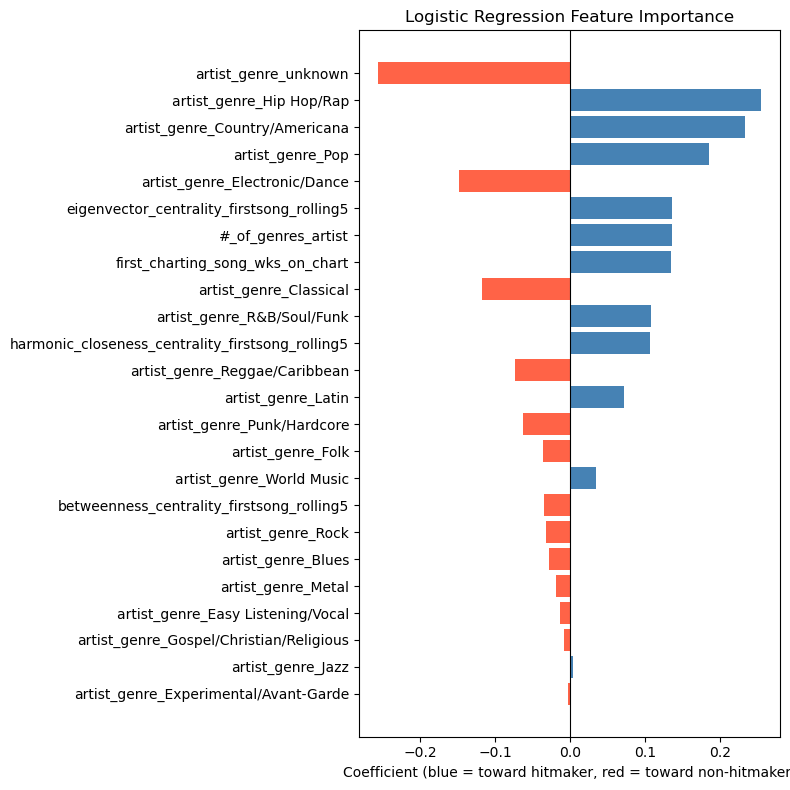

In [29]:
    # --- Logistic Regression: coefficient-based feature importance ---
    if name == 'Logistic Regression':
        # Extract coefficients from pipeline
        coefs = model.named_steps['clf'].coef_[0]
        lr_importance = (
            pd.DataFrame({
                'feature':    X_te.columns,
                'coefficient': coefs,
                'abs_coef':   np.abs(coefs)
            })
            .sort_values('abs_coef', ascending=False)
            .reset_index(drop=True)
        )

        print(f"\nFeature Importance (coefficients) — Logistic Regression:")
        print(lr_importance[['feature', 'coefficient']].to_string(index=False))

        fig, ax = plt.subplots(figsize=(8, 8))
        colors = ['steelblue' if c > 0 else 'tomato' for c in lr_importance['coefficient'][::-1]]
        ax.barh(lr_importance['feature'][::-1], lr_importance['coefficient'][::-1], color=colors)
        ax.axvline(0, color='black', linewidth=0.8)
        ax.set_xlabel('Coefficient (blue = toward hitmaker, red = toward non-hitmaker)')
        ax.set_title('Logistic Regression Feature Importance')
        plt.tight_layout()
        plt.show()


#### Trying XGBoost with genre_unknown column dropped

In [30]:
# Test XGBoost with artist_genre_unknown dropped.
# Uses same best params from tuning.

X_train_no_unknown = X_train.drop(columns=['artist_genre_unknown'], errors='ignore')
X_test_no_unknown  = X_test.drop(columns=['artist_genre_unknown'], errors='ignore')

model_no_unknown = XGBClassifier(
    random_state=42, eval_metric='logloss',
    **xgb_search.best_params_
)

cv = cross_validate(model_no_unknown, X_train_no_unknown, y_train, cv=5,
                    scoring='roc_auc', return_train_score=True)
model_no_unknown.fit(X_train_no_unknown, y_train)
y_proba_no_unknown = model_no_unknown.predict_proba(X_test_no_unknown)[:, 1]

print("Without artist_genre_unknown:")
print(f"  ROC-AUC (CV):    {cv['test_score'].mean():.3f} ± {cv['test_score'].std():.3f}")
print(f"  ROC-AUC (Train): {cv['train_score'].mean():.3f}")
print(f"  ROC-AUC (Test):  {roc_auc_score(y_test, y_proba_no_unknown):.3f}")
print(f"  Overfit Gap:     {cv['train_score'].mean() - cv['test_score'].mean():.3f}")

print("\nWith artist_genre_unknown (reference):")
print(f"  ROC-AUC (CV):    0.744")
print(f"  ROC-AUC (Test):  0.749")


Without artist_genre_unknown:
  ROC-AUC (CV):    0.741 ± 0.038
  ROC-AUC (Train): 0.774
  ROC-AUC (Test):  0.746
  Overfit Gap:     0.034

With artist_genre_unknown (reference):
  ROC-AUC (CV):    0.744
  ROC-AUC (Test):  0.749
